In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('dates.csv')

In [4]:
df.columns

Index(['gender', 'age', 'age_o', 'field', 'pref_o_attractive',
       'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny',
       'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_o',
       'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o',
       'shared_interests_o', 'attractive', 'sincere', 'intelligence', 'funny',
       'ambition', 'attractive_partner', 'sincere_partner',
       'intelligence_partner', 'funny_partner', 'ambition_partner',
       'shared_interests_partner', 'sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga',
       'expected_happy_with_sd_people', 'expected_num_interested_in_me',
       'expected_num_matches', 'like', 'met', 'decision', 'decision_o',
       'match'],
      dtype='str')

In [28]:
from sklearn import tree
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [7]:
X = df.drop(['decision', 'decision_o', 'match'], axis=1)
y = df['match']

In [8]:
y.value_counts()

match
0    862
1    186
Name: count, dtype: int64

In [10]:
X = pd.get_dummies(X, drop_first=True)

In [15]:
X.columns

Index(['age', 'age_o', 'pref_o_attractive', 'pref_o_sincere',
       'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
       'pref_o_shared_interests', 'attractive_o', 'sinsere_o',
       'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
       'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
       'attractive_partner', 'sincere_partner', 'intelligence_partner',
       'funny_partner', 'ambition_partner', 'shared_interests_partner',
       'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking',
       'gaming', 'clubbing', 'reading', 'tv', 'theater', 'movies', 'concerts',
       'music', 'shopping', 'yoga', 'expected_happy_with_sd_people',
       'expected_num_interested_in_me', 'expected_num_matches', 'like', 'met',
       'gender_male', 'field_Art History/Medicine',
       'field_Biomedical Engineering', 'field_Business',
       'field_Business & International Affairs', 'field_Business [Mba]',
       'field_Business- Mba', 'field

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

In [29]:
dt = tree.DecisionTreeClassifier(
    random_state=42, 
    max_depth=5
)

In [30]:
dt.fit(X=X_train, y=y_train) # train the model
y_test_pred = dt.predict(X_test) # make predictions based on the test set


print(metrics.accuracy_score(y_test, y_test_pred))

0.7904761904761904


In [ ]:
knn = KNeighborsClassifier(n_neighbors=9) # KNN - K-Nearest Neighbors

knn.fit(X=X_train, y=y_train)

y_test_pred_knn = knn.predict(X_test)

print(metrics.accuracy_score(y_test, y_test_pred_knn))

0.8333333333333334


In [32]:
print(metrics.confusion_matrix(y_test, y_test_pred))

[[155  18]
 [ 26  11]]


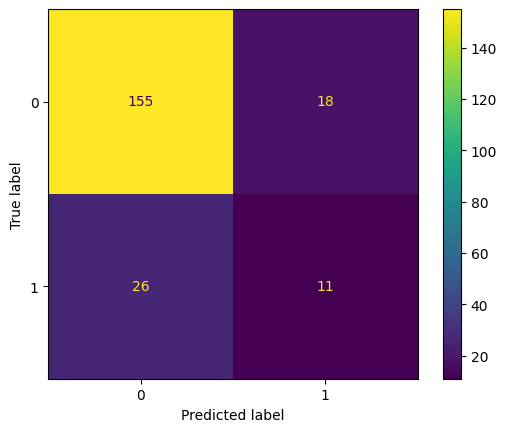

In [33]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()